# Graded Response Model — Single Scale

This notebook fits a standard **GRModel** (single latent dimension) to all 22
RWA items, treating the entire questionnaire as measuring one underlying
construct.

Two models are fit:
1. **Baseline** — ignorable missingness (missing responses have their log-likelihood zeroed out)
2. **Imputed** — missing responses are handled via **MICEBayesianLOO** imputation, using analytic Rao-Blackwellization

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ['JAX_PLATFORMS'] = 'cpu'

import numpy as np
import pandas as pd
import polars as pl
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from bayesianquilts.data.rwa import get_data, item_keys
from bayesianquilts.irt.grm import GRModel
from bayesianquilts.imputation.mice_loo import MICEBayesianLOO

## 1. Load the RWA Dataset

In [2]:
response_cardinality = 9

df, num_people = get_data(polars_out=True)
print(f"Dataset: {num_people} people, {len(item_keys)} items, {response_cardinality} response categories (0-8)")
df.head()

Dataset: 9881 people, 22 items, 9 response categories (0-8)


person,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q15,Q16,Q17,Q18,Q19,Q20,Q21,Q22
u32,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64
0,3,0,0,8,2,8,1,6,7,0,8,0,8,0,8,0,0,8,1,8,8,0
1,2,1,0,7,1,6,0,7,8,2,6,4,8,1,8,0,0,7,0,6,6,0
2,0,5,6,8,2,8,8,3,8,8,7,8,8,7,8,1,8,2,4,6,8,8
3,0,0,0,7,0,7,0,8,8,0,8,1,7,0,7,0,0,8,0,8,8,0
4,0,0,0,2,0,8,0,0,6,0,8,1,8,4,8,0,0,2,0,8,3,0


In [3]:
SUBSAMPLE_N = num_people
sub_df = df
print(f"Using full dataset: N = {SUBSAMPLE_N}")

Using full dataset: N = 9881


## 2. Prepare Data and Fit the Baseline GRM

We use `GRModel` with `dim=1` so that all 22 items load on a single
latent trait. Missing/invalid responses (if any) have their
log-likelihood zeroed out (ignorable missingness).

In [4]:
def make_data_dict(dataframe):
    """Convert polars DataFrame to dict of numpy float64 arrays."""
    data = {}
    for col in dataframe.columns:
        arr = dataframe[col].to_numpy().astype(np.float64)
        data[col] = arr
    data['person'] = np.arange(len(dataframe), dtype=np.float64)
    return data

batch = make_data_dict(sub_df)

# Check for missing/invalid values
n_bad = sum(
    np.sum(np.isnan(batch[k]) | (batch[k] < 0) | (batch[k] >= response_cardinality))
    for k in item_keys
)
print(f"Bad/missing values: {n_bad}")

BATCH_SIZE = 256
steps_per_epoch = int(np.ceil(SUBSAMPLE_N / BATCH_SIZE))
print(f"N: {SUBSAMPLE_N}, Batch size: {BATCH_SIZE}, Steps per epoch: {steps_per_epoch}")

def data_factory():
    indices = np.arange(SUBSAMPLE_N)
    np.random.shuffle(indices)
    for start in range(0, SUBSAMPLE_N, BATCH_SIZE):
        end = min(start + BATCH_SIZE, SUBSAMPLE_N)
        idx_batch = indices[start:end]
        yield {k: v[idx_batch] for k, v in batch.items()}

Bad/missing values: 352
N: 9881, Batch size: 256, Steps per epoch: 39


In [ ]:
model_baseline = GRModel(
    item_keys=item_keys,
    num_people=SUBSAMPLE_N,
    dim=1,
    kappa_scale=0.1,
    response_cardinality=response_cardinality,
    dtype=jnp.float64,
)

NUM_EPOCHS = 200
SNAPSHOT_EPOCH = 50

res_baseline = model_baseline.fit(
    data_factory,
    batch_size=BATCH_SIZE,
    dataset_size=SUBSAMPLE_N,
    num_epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    learning_rate=2e-4,
    patience=10,
    zero_nan_grads=True,
    snapshot_epoch=SNAPSHOT_EPOCH,
)

losses_baseline = res_baseline[0]
snapshot_params = res_baseline[2] if len(res_baseline) > 2 else None
print(f"Baseline final loss: {losses_baseline[-1]:.2f}")
if snapshot_params is not None:
    print(f"Snapshot saved at epoch {SNAPSHOT_EPOCH}")

In [6]:
model_baseline.save_to_disk('grm_baseline')
print("Baseline model saved to grm_baseline/")

Baseline model saved to grm_baseline/


In [ ]:
# Calibrate baseline model early so we can compute WAIC for mixed imputation
def calibrate_manually(model, n_samples=32, seed=42):
    surrogate = model.surrogate_distribution_generator(model.params)
    key = jax.random.PRNGKey(seed)
    samples = surrogate.sample(n_samples, seed=key)
    expectations = {k: jnp.mean(v, axis=0) for k, v in samples.items()}
    model.calibrated_expectations = expectations
    model.surrogate_sample = samples

calibrate_manually(model_baseline, n_samples=32, seed=101)

## 3. Fit MICEBayesianLOO Imputation Model

We build pairwise univariate imputation models for each item pair
using **MICEBayesianLOO** with Pathfinder variational inference.
This allows us to predict a full categorical PMF over the 9 response
categories for any missing cell, conditioned on the observed items
in that row.

In [7]:
# Convert to pandas and replace the -1 missing code with NaN
imputation_df = sub_df.select(item_keys).to_pandas()
imputation_df = imputation_df.replace(-1, float('nan'))

print(f"Imputation DataFrame shape: {imputation_df.shape}")
print(f"Missing values per item:")
print(imputation_df.isna().sum())

Imputation DataFrame shape: (9881, 22)
Missing values per item:
Q1     13
Q2      7
Q3     24
Q4     22
Q5     13
Q6      8
Q7     14
Q8     14
Q9     29
Q10    17
Q11    23
Q12    32
Q13    14
Q14    21
Q15    16
Q16    10
Q17    13
Q18     9
Q19    11
Q20    16
Q21    15
Q22    11
dtype: int64


In [ ]:
mice_loo = MICEBayesianLOO(
    prior_scale=1.0,
    pathfinder_num_samples=100,
    pathfinder_maxiter=50,
    batch_size=512,
    verbose=True,
)

mice_loo.fit_loo_models(
    imputation_df,
    n_top_features=22,
    n_jobs=1,
    fit_zero_predictors=True,
)

print("\nMICE LOO model fitting complete.")

In [9]:
mice_loo.save('mice_loo_model.yaml')
print("MICE LOO model saved to mice_loo_model.yaml")

MICE LOO model saved to mice_loo_model.yaml


In [ ]:
from bayesianquilts.imputation.mixed import IrtMixedImputationModel

mixed_imputation = IrtMixedImputationModel(
    irt_model=model_baseline,
    mice_model=mice_loo,
    data_factory=data_factory,
    irt_elpd_batch_size=4,
)

print(mixed_imputation.summary())

## 4. Fit GRM with Imputation

We now fit a second GRM that uses the trained `MICEBayesianLOO` model
to analytically marginalize over the imputation distribution for
missing cells (Rao-Blackwellization). Instead of discarding missing
observations, the model computes:

$$\text{contribution} = \log \sum_k q(k) \, p(Y=k \mid \phi)$$

where $q(k)$ is the imputation PMF and $p(Y=k \mid \phi)$ is the
GRM probability under the current parameters.

In [ ]:
model_imputed = GRModel(
    item_keys=item_keys,
    num_people=SUBSAMPLE_N,
    dim=1,
    kappa_scale=0.1,
    response_cardinality=response_cardinality,
    dtype=jnp.float64,
    imputation_model=mixed_imputation,
)

if snapshot_params is not None:
    print(f"Warm-starting from baseline epoch-{SNAPSHOT_EPOCH} snapshot")

res_imputed = model_imputed.fit(
    data_factory,
    batch_size=BATCH_SIZE,
    dataset_size=SUBSAMPLE_N,
    num_epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    learning_rate=2e-4,
    patience=10,
    zero_nan_grads=True,
    initial_values=snapshot_params,
)

losses_imputed = res_imputed[0]
print(f"Imputed final loss: {losses_imputed[-1]:.2f}")

In [11]:
model_imputed.save_to_disk('grm_imputed')
print("Imputed model saved to grm_imputed/")

Imputed model saved to grm_imputed/


## 5. Training Diagnostics

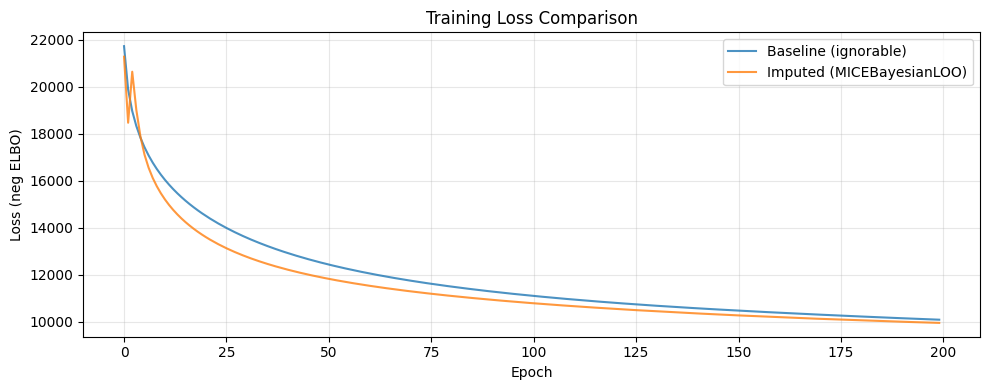

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(losses_baseline, alpha=0.8, label='Baseline (ignorable)')
plt.plot(losses_imputed, alpha=0.8, label='Imputed (MICEBayesianLOO)')
plt.xlabel('Epoch')
plt.ylabel('Loss (neg ELBO)')
plt.title('Training Loss Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Posterior Parameter Estimates

In [ ]:
# calibrate_manually already defined above; just calibrate the imputed model
calibrate_manually(model_imputed, n_samples=32, seed=102)

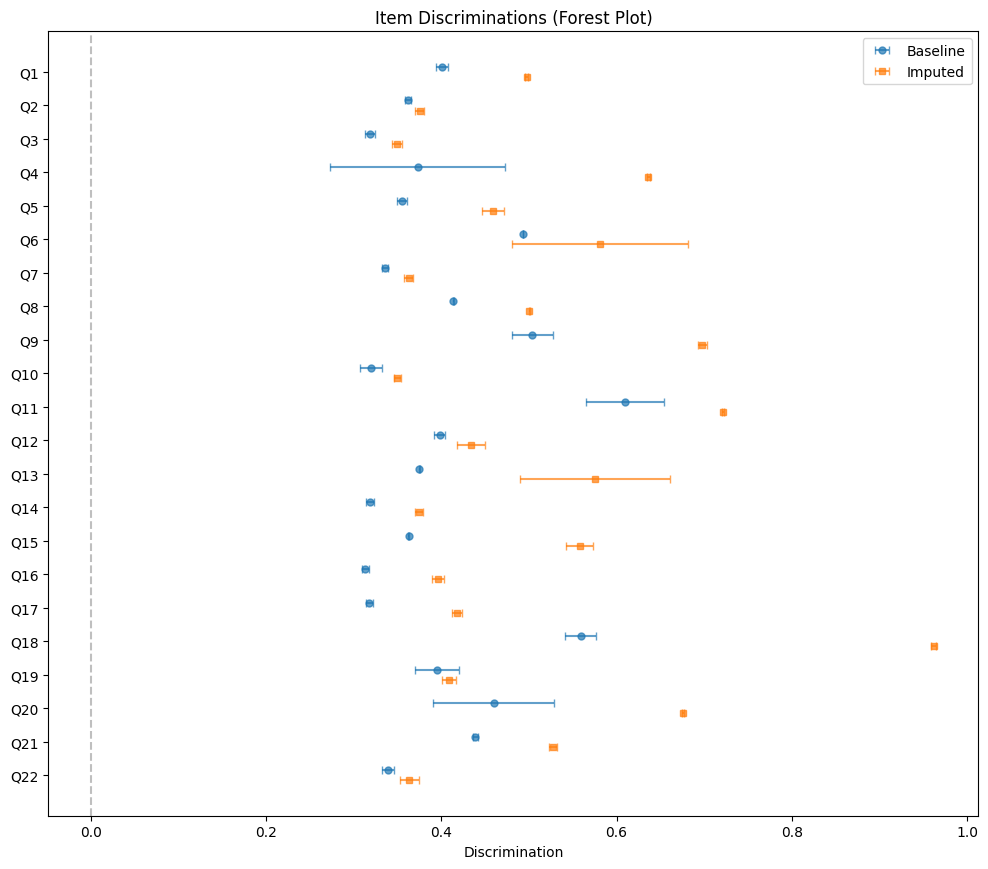

In [14]:
# Forest plot of discriminations with uncertainty
disc_samples_base = np.array(model_baseline.surrogate_sample['discriminations']).reshape(
    -1, len(item_keys))
disc_samples_imp = np.array(model_imputed.surrogate_sample['discriminations']).reshape(
    -1, len(item_keys))

disc_mean_base = disc_samples_base.mean(axis=0)
disc_std_base = disc_samples_base.std(axis=0)
disc_mean_imp = disc_samples_imp.mean(axis=0)
disc_std_imp = disc_samples_imp.std(axis=0)

fig, ax = plt.subplots(figsize=(10, max(7, len(item_keys) * 0.4)))
y_pos = np.arange(len(item_keys))
offset = 0.15

ax.errorbar(disc_mean_base, y_pos - offset, xerr=disc_std_base, fmt='o',
            capsize=3, markersize=5, elinewidth=1.5, color='tab:blue',
            ecolor='tab:blue', alpha=0.7, label='Baseline')
ax.errorbar(disc_mean_imp, y_pos + offset, xerr=disc_std_imp, fmt='s',
            capsize=3, markersize=5, elinewidth=1.5, color='tab:orange',
            ecolor='tab:orange', alpha=0.7, label='Imputed')

ax.set_yticks(y_pos)
ax.set_yticklabels(item_keys)
ax.set_xlabel('Discrimination')
ax.set_title('Item Discriminations (Forest Plot)')
ax.legend()
ax.invert_yaxis()
ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
abilities_baseline = np.array(model_baseline.calibrated_expectations['abilities']).flatten()
abilities_imputed = np.array(model_imputed.calibrated_expectations['abilities']).flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatterplot
ax = axes[0]
ax.scatter(abilities_baseline, abilities_imputed, alpha=0.3, s=10, edgecolors='none')
lims = [min(abilities_baseline.min(), abilities_imputed.min()),
        max(abilities_baseline.max(), abilities_imputed.max())]
ax.plot(lims, lims, 'k--', alpha=0.5, label='y = x')
ax.set_xlabel('Baseline Ability')
ax.set_ylabel('Imputed Ability')
ax.set_title('Ability Estimates: Baseline vs Imputed')
ax.legend()
ax.set_aspect('equal')

# Step histograms (no filled overlap)
ax = axes[1]
ax.hist(abilities_baseline, bins=30, histtype='step', linewidth=2, label='Baseline', color='tab:blue')
ax.hist(abilities_imputed, bins=30, histtype='step', linewidth=2, label='Imputed', color='tab:orange')
ax.set_xlabel('Ability (RWA latent trait)')
ax.set_ylabel('Count')
ax.set_title('Ability Distribution')
ax.legend()

plt.tight_layout()
plt.show()

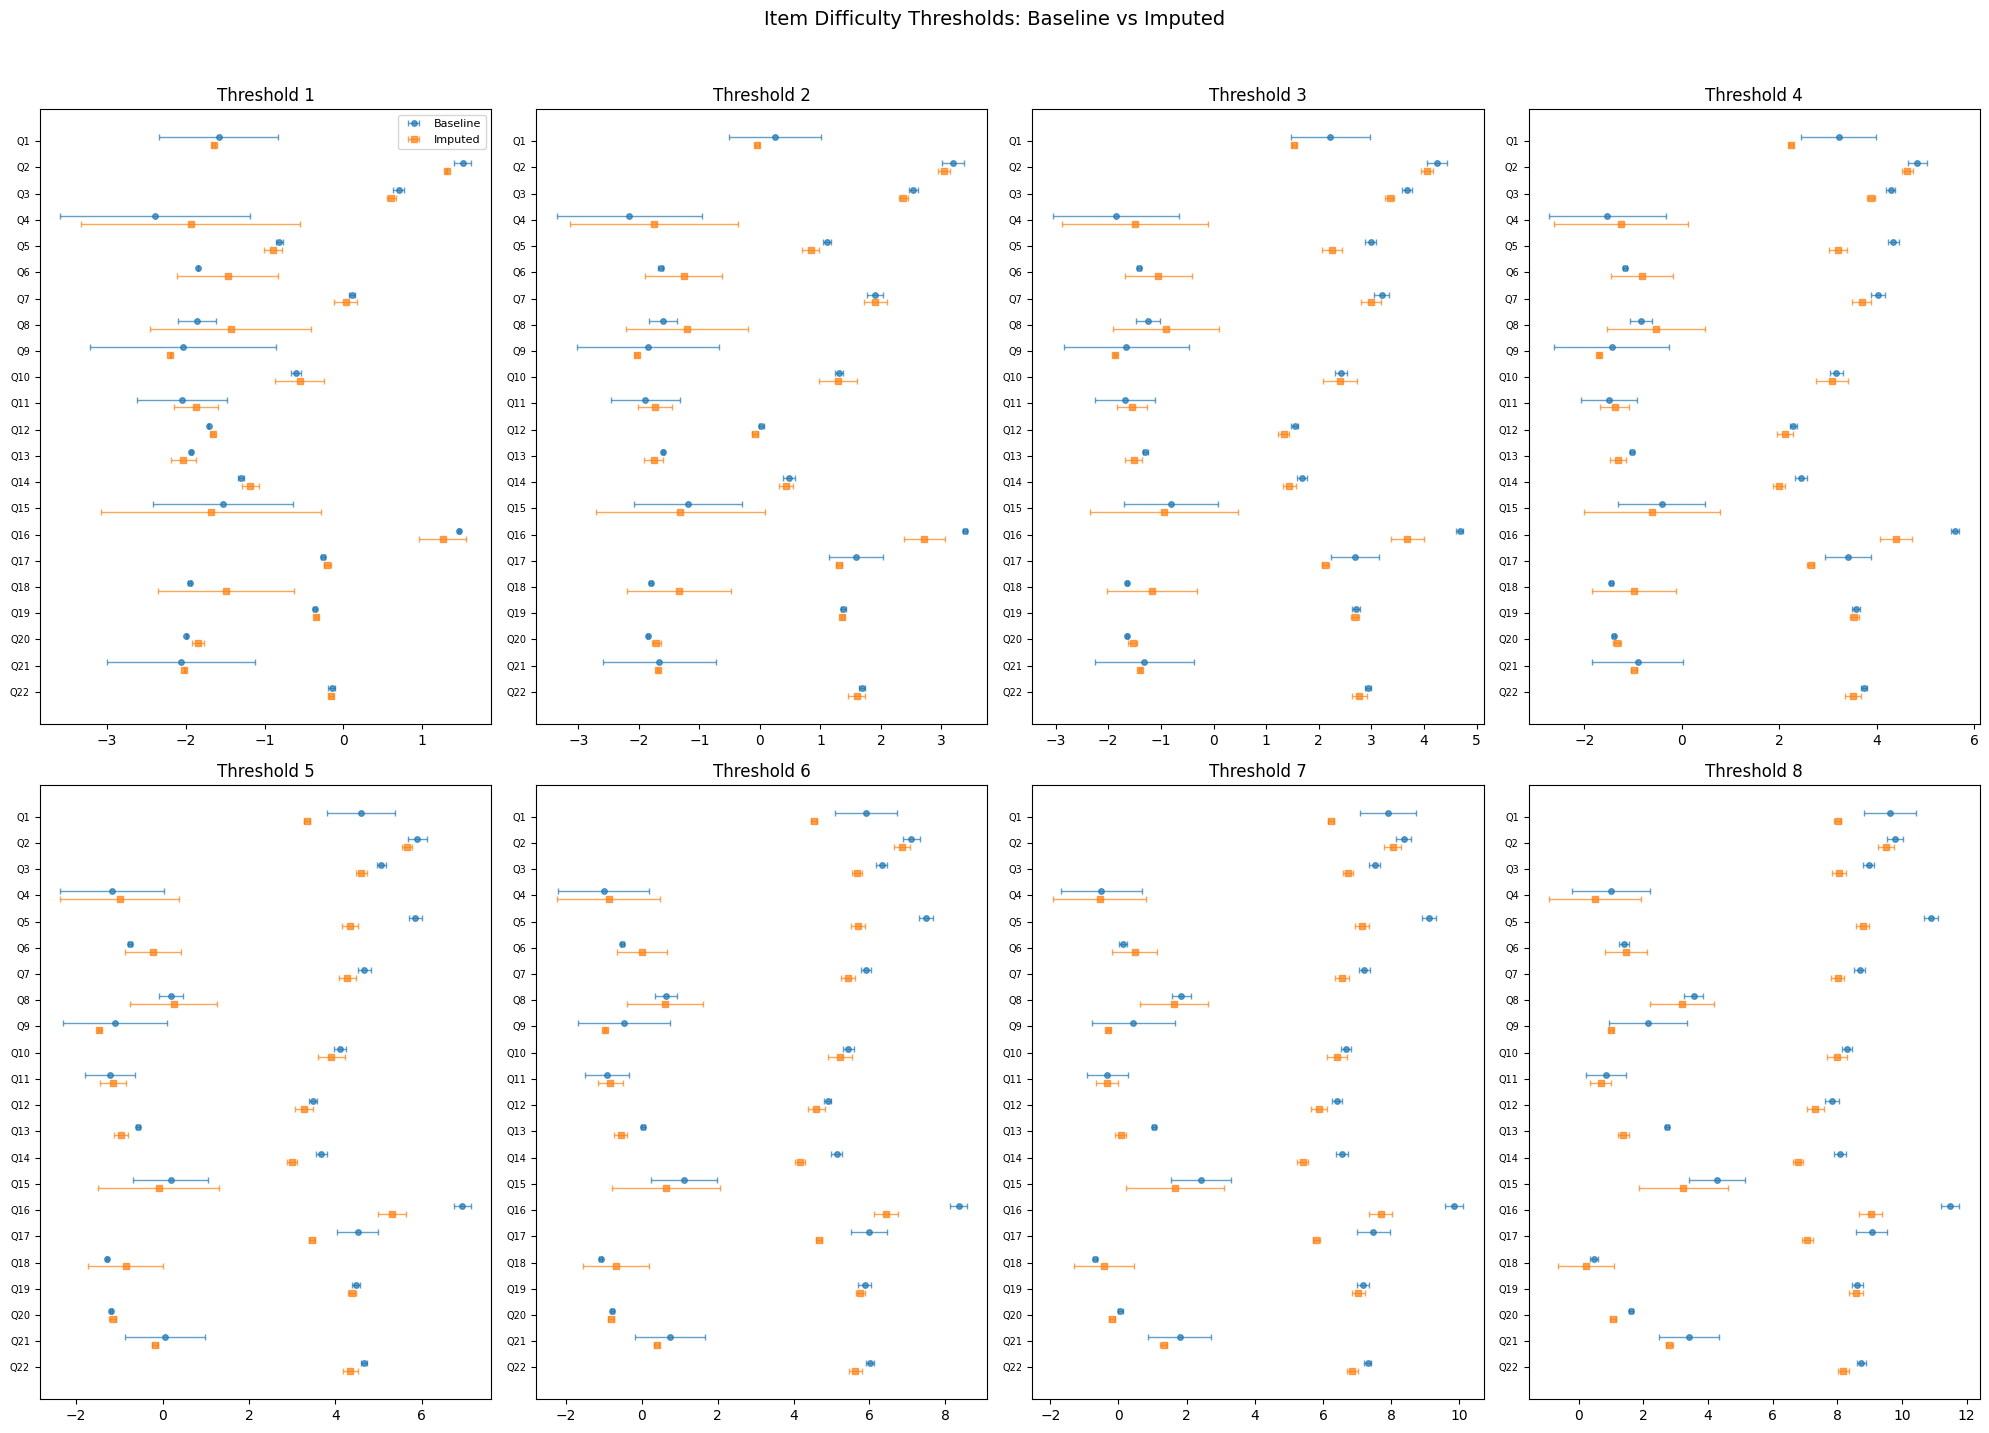

In [16]:
# Difficulty threshold comparison (panel for each level)
def compute_thresholds(model):
    diff0 = np.array(model.surrogate_sample['difficulties0'])
    ddiff = np.array(model.surrogate_sample['ddifficulties'])
    d0 = np.concatenate([diff0, ddiff], axis=-1)
    thresholds = np.cumsum(d0, axis=-1)
    n_samples = thresholds.shape[0]
    n_thresholds = thresholds.size // (n_samples * len(item_keys))
    return thresholds.reshape(n_samples, len(item_keys), n_thresholds)

thresh_base = compute_thresholds(model_baseline)
thresh_imp = compute_thresholds(model_imputed)

K_minus_1 = thresh_base.shape[-1]
n_cols = min(4, K_minus_1)
n_rows = int(np.ceil(K_minus_1 / n_cols))

fig, axes = plt.subplots(n_rows, n_cols,
    figsize=(5 * n_cols, max(7, len(item_keys) * 0.3) * n_rows),
    squeeze=False)

for level in range(K_minus_1):
    ax = axes[level // n_cols, level % n_cols]
    y_pos = np.arange(len(item_keys))

    mean_base = thresh_base[:, :, level].mean(axis=0)
    std_base = thresh_base[:, :, level].std(axis=0)
    mean_imp = thresh_imp[:, :, level].mean(axis=0)
    std_imp = thresh_imp[:, :, level].std(axis=0)

    offset = 0.15
    ax.errorbar(mean_base, y_pos - offset, xerr=std_base, fmt='o',
                capsize=2, markersize=4, elinewidth=1, color='tab:blue',
                alpha=0.7, label='Baseline')
    ax.errorbar(mean_imp, y_pos + offset, xerr=std_imp, fmt='s',
                capsize=2, markersize=4, elinewidth=1, color='tab:orange',
                alpha=0.7, label='Imputed')

    ax.set_yticks(y_pos)
    ax.set_yticklabels(item_keys, fontsize=max(5, 8 - len(item_keys) // 20))
    ax.set_title(f'Threshold {level + 1}')
    ax.invert_yaxis()
    if level == 0:
        ax.legend(fontsize=8)

for idx in range(K_minus_1, n_rows * n_cols):
    axes[idx // n_cols, idx % n_cols].set_visible(False)

fig.suptitle('Item Difficulty Thresholds: Baseline vs Imputed', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

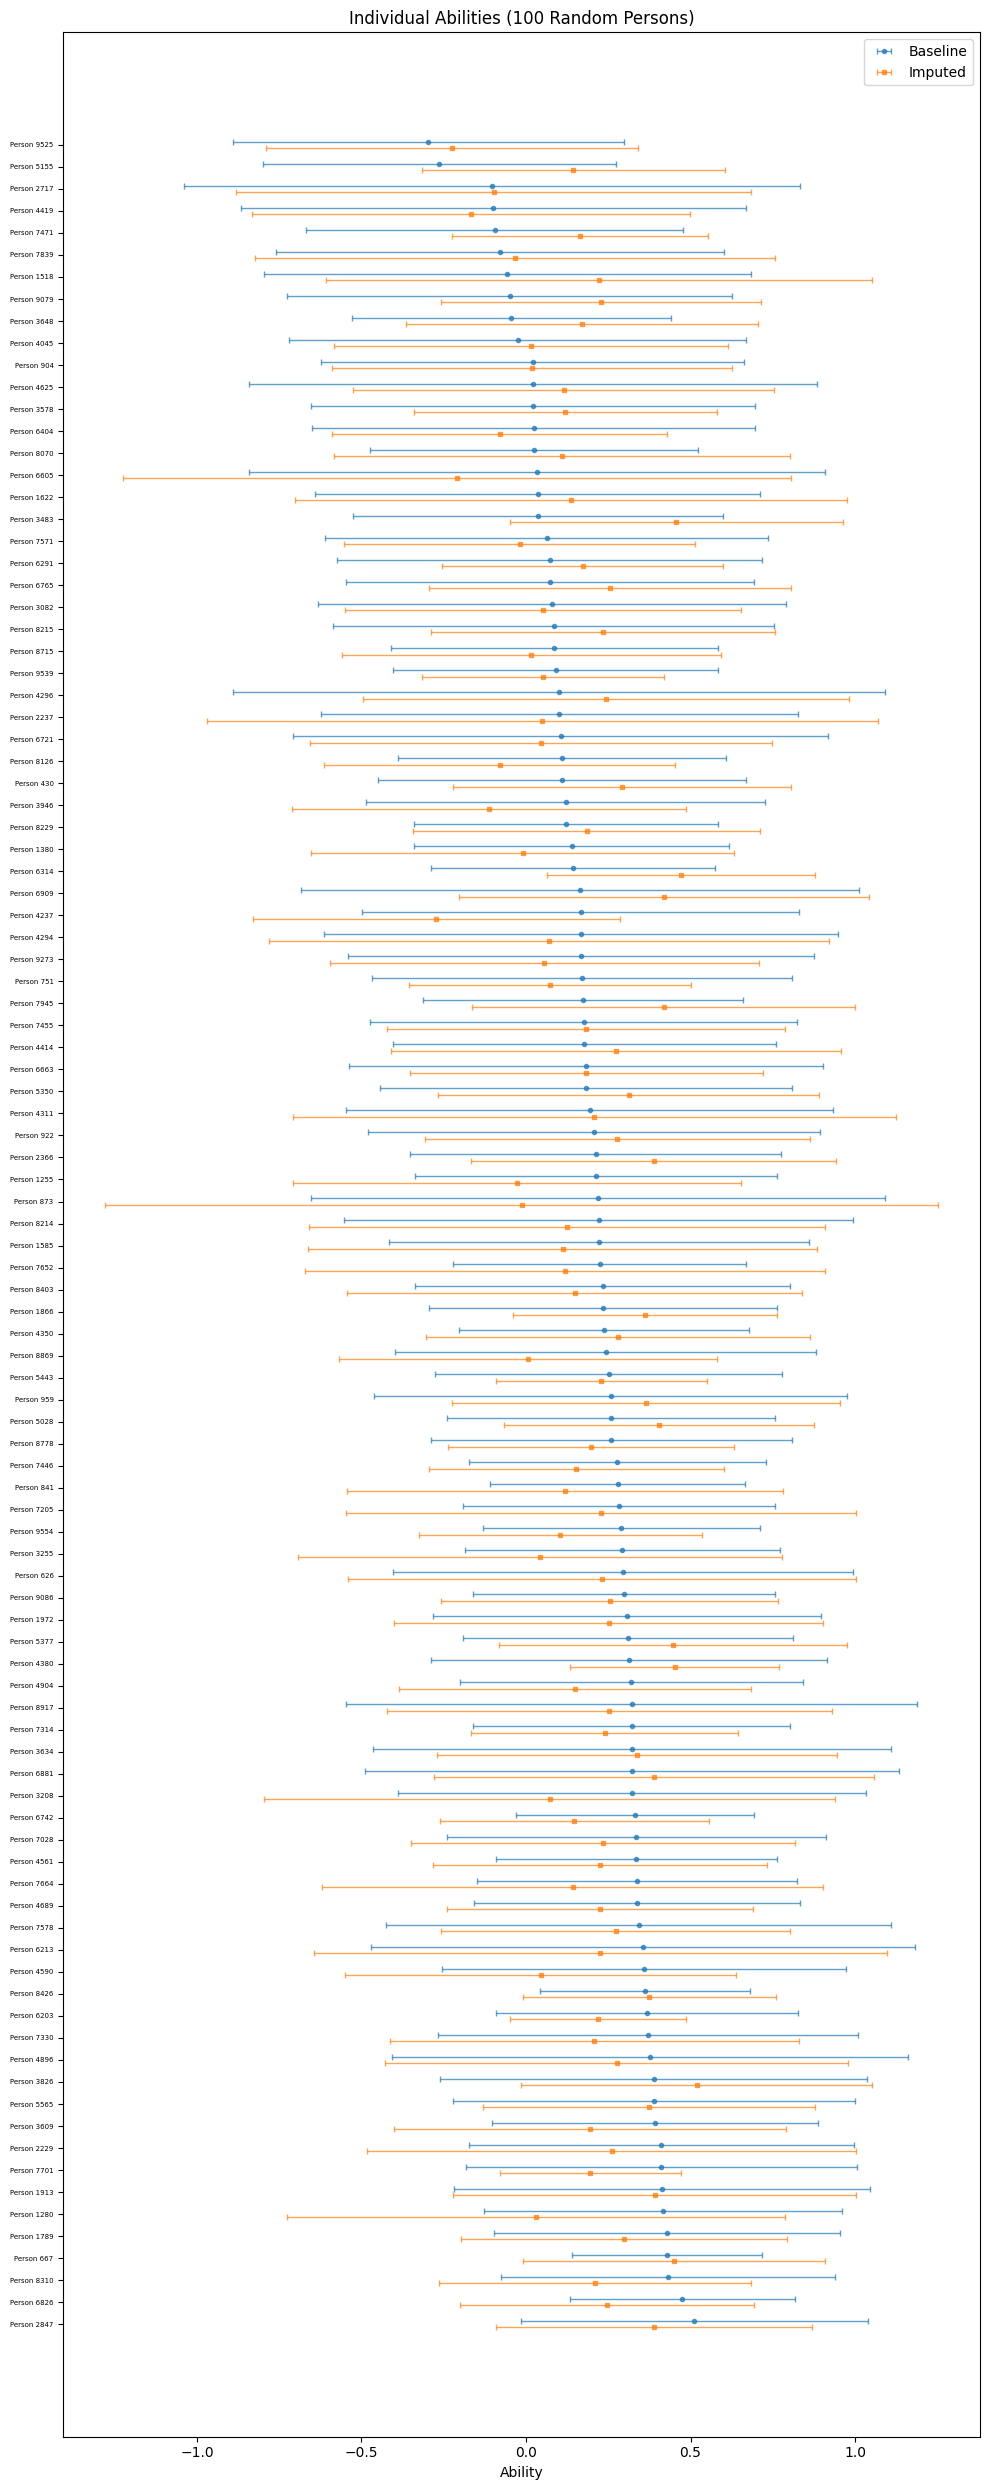

In [17]:
# Forest plot comparing abilities for 100 random individuals
ab_samples_base = np.array(model_baseline.surrogate_sample['abilities'])
ab_samples_imp = np.array(model_imputed.surrogate_sample['abilities'])

# Flatten to (S, N)
ab_samples_base = ab_samples_base.reshape(ab_samples_base.shape[0], -1)
ab_samples_imp = ab_samples_imp.reshape(ab_samples_imp.shape[0], -1)

N = ab_samples_base.shape[1]
rng = np.random.default_rng(42)
idx = rng.choice(N, size=min(100, N), replace=False)
idx = np.sort(idx)

ab_mean_base = ab_samples_base[:, idx].mean(axis=0)
ab_std_base = ab_samples_base[:, idx].std(axis=0)
ab_mean_imp = ab_samples_imp[:, idx].mean(axis=0)
ab_std_imp = ab_samples_imp[:, idx].std(axis=0)

# Sort by baseline mean for readability
order = np.argsort(ab_mean_base)
ab_mean_base = ab_mean_base[order]
ab_std_base = ab_std_base[order]
ab_mean_imp = ab_mean_imp[order]
ab_std_imp = ab_std_imp[order]

fig, ax = plt.subplots(figsize=(10, 25))
y_pos = np.arange(len(idx))
offset = 0.15

ax.errorbar(ab_mean_base, y_pos - offset, xerr=ab_std_base, fmt='o',
            capsize=2, markersize=3, elinewidth=1, color='tab:blue',
            alpha=0.7, label='Baseline')
ax.errorbar(ab_mean_imp, y_pos + offset, xerr=ab_std_imp, fmt='s',
            capsize=2, markersize=3, elinewidth=1, color='tab:orange',
            alpha=0.7, label='Imputed')

ax.set_yticks(y_pos)
ax.set_yticklabels([f'Person {i}' for i in idx[order]], fontsize=5)
ax.set_xlabel('Ability')
ax.set_title('Individual Abilities (100 Random Persons)')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated two approaches to fitting a single-scale Graded
Response Model to all 22 RWA items using `GRModel` with `dim=1`:

1. **Baseline (ignorable missingness)** — missing responses are effectively
   skipped by zeroing out their log-likelihood contribution.

2. **MICEBayesianLOO imputation** — a pairwise Bayesian imputation model
   is trained to predict each missing cell's categorical PMF from the
   observed items in the same row. The GRM then analytically marginalizes
   over the imputation distribution (Rao-Blackwellization), yielding
   zero-variance contributions for missing cells.

The side-by-side discrimination and ability plots above allow direct
comparison of the two strategies. When missingness is informative
(non-ignorable), the imputed model is expected to produce less biased
parameter estimates.